In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load the Datasets
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

uci_diabetes = pd.read_csv(url, names=columns)
pima_diabetes = pd.read_csv(url, names=columns)

In [2]:
# Select Features and Target Variable
features = ["Glucose", "BloodPressure", "Age"]
target = "BMI"

# UCI Dataset
X_uci = uci_diabetes[features]
y_uci = uci_diabetes[target]

# Pima Dataset
X_pima = pima_diabetes[features]
y_pima = pima_diabetes[target]

# Split the Dataset into Training and Testing Sets
X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=42
)

X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima, y_pima, test_size=0.2, random_state=42
)

# Train the Linear Regression Model
model_uci = LinearRegression()
model_uci.fit(X_train_uci, y_train_uci)

model_pima = LinearRegression()
model_pima.fit(X_train_pima, y_train_pima)

# Make Predictions
y_pred_uci = model_uci.predict(X_test_uci)
y_pred_pima = model_pima.predict(X_test_pima)

In [3]:
# Evaluate Model Performance
r2_uci = r2_score(y_test_uci, y_pred_uci)
mse_uci = mean_squared_error(y_test_uci, y_pred_uci)
mae_uci = mean_absolute_error(y_test_uci, y_pred_uci)

r2_pima = r2_score(y_test_pima, y_pred_pima)
mse_pima = mean_squared_error(y_test_pima, y_pred_pima)
mae_pima = mean_absolute_error(y_test_pima, y_pred_pima)

# Display Results
print("UCI Diabetes Dataset - Linear Regression Results:")
print(f"R² Score: {r2_uci:.4f}, MSE: {mse_uci:.4f}, MAE: {mae_uci:.4f}")

print("\nPima Indians Diabetes Dataset - Linear Regression Results:")
print(f"R² Score: {r2_pima:.4f}, MSE: {mse_pima:.4f}, MAE: {mae_pima:.4f}")

UCI Diabetes Dataset - Linear Regression Results:
R² Score: 0.1677, MSE: 59.1631, MAE: 5.7335

Pima Indians Diabetes Dataset - Linear Regression Results:
R² Score: 0.1677, MSE: 59.1631, MAE: 5.7335


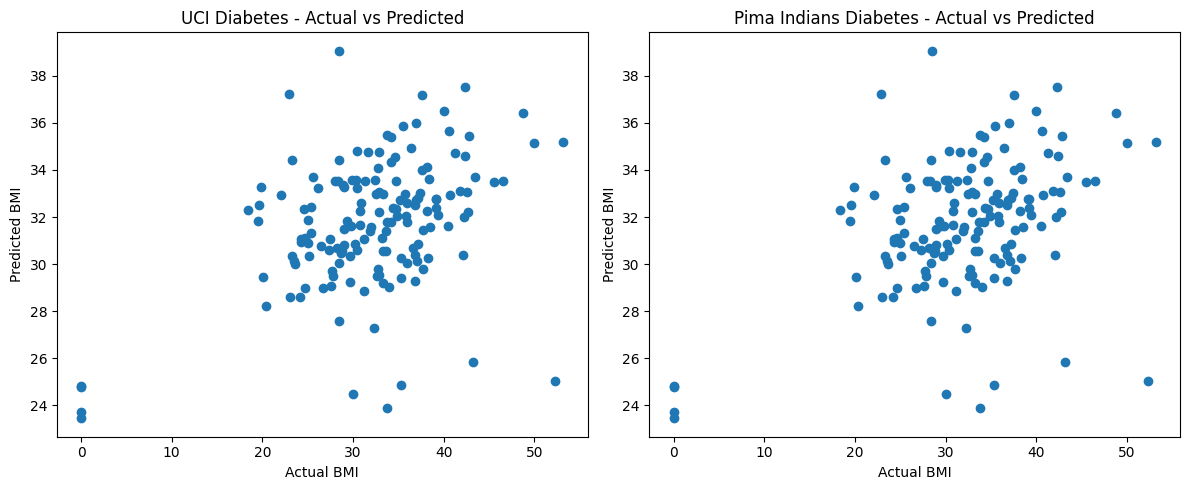

In [4]:
# Visualize Predictions vs Actual Values

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_uci, y_pred_uci)
plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("UCI Diabetes - Actual vs Predicted")

plt.subplot(1, 2, 2)
plt.scatter(y_test_pima, y_pred_pima)
plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Pima Indians Diabetes - Actual vs Predicted")

plt.tight_layout()
plt.show()